In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

train = pd.read_csv("data/raw/train.csv", low_memory=False)
store = pd.read_csv("data/raw/store.csv")
test = pd.read_csv("data/raw/test.csv")

print("Train:", train.shape)
print("Store:", store.shape)
print("Test:", test.shape)

Train: (1017209, 9)
Store: (1115, 10)
Test: (41088, 8)


In [3]:
import os

print(os.getcwd())
print(os.listdir())


C:\Users\Shrey\OneDrive\Desktop\stocksense
['.git', '.gitignore', '.ipynb_checkpoints', '.venv', '01_data_inspection.ipynb', 'app', 'configs', 'data', 'models', 'notebooks', 'README.md', 'requirements.txt', 'src', 'tests']


In [5]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   Store          1017209 non-null  int64
 1   DayOfWeek      1017209 non-null  int64
 2   Date           1017209 non-null  str  
 3   Sales          1017209 non-null  int64
 4   Customers      1017209 non-null  int64
 5   Open           1017209 non-null  int64
 6   Promo          1017209 non-null  int64
 7   StateHoliday   1017209 non-null  str  
 8   SchoolHoliday  1017209 non-null  int64
dtypes: int64(7), str(2)
memory usage: 69.8 MB


In [7]:
train.describe()


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [8]:
train.columns


Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='str')

In [9]:

store.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

In [10]:
train["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [11]:
train["Customers"].describe()

count    1.017209e+06
mean     6.331459e+02
std      4.644117e+02
min      0.000000e+00
25%      4.050000e+02
50%      6.090000e+02
75%      8.370000e+02
max      7.388000e+03
Name: Customers, dtype: float64

In [12]:
train["Promo"].value_counts()

Promo
0    629129
1    388080
Name: count, dtype: int64

In [13]:
train["Open"].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [14]:
train["StateHoliday"].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [15]:
train["Store"].nunique()

1115

In [16]:
train["Date"].min(), train["Date"].max()

('2013-01-01', '2015-07-31')

In [17]:
train["Date"] = pd.to_datetime(train["Date"])

daily_sales = train.groupby("Date")["Sales"].sum()

daily_sales.head()

Date
2013-01-01      97235
2013-01-02    6949829
2013-01-03    6347820
2013-01-04    6638954
2013-01-05    5951593
Name: Sales, dtype: int64

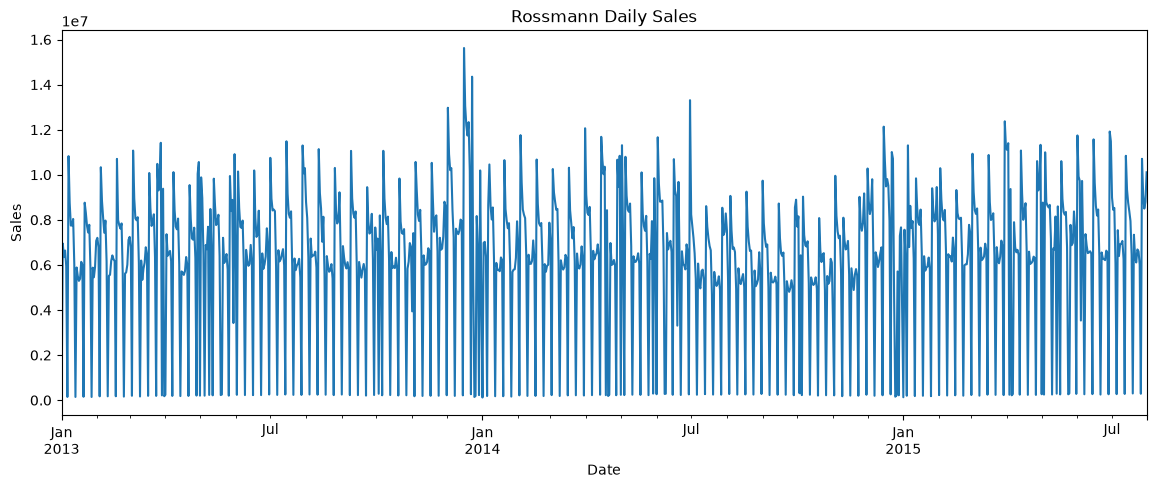

In [18]:
plt.figure(figsize=(14, 5))

daily_sales.plot()

plt.title("Rossmann Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

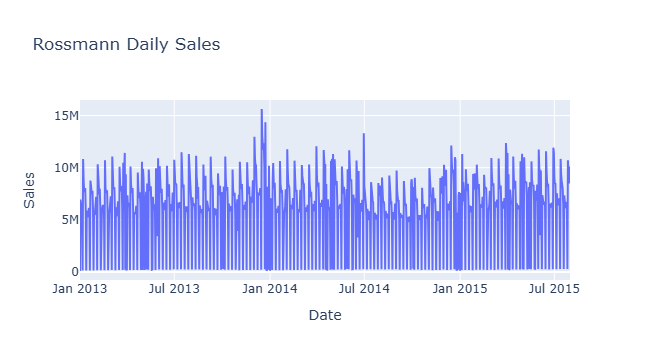

In [19]:
df_plot = daily_sales.reset_index()

fig = px.line(
    df_plot,
    x="Date",
    y="Sales",
    title="Rossmann Daily Sales"
)

fig.show()

In [22]:
# Time Series Fundamentals

## 1. Demand Forecasting

Demand forecasting means using past sales data and patterns to estimate future demand.

Past sales
↓
Patterns
↓
Forecast
↓
Future demand

Example:

Store 10

Monday → 8,000  
Tuesday → 8,400  
Wednesday → 8,100  
Thursday → 8,700  
Friday → 9,200  

Future:

Saturday → ?  
Sunday → ?

---

## 2. Time-Series Data

Time-series data is data where time/order matters.

For StockSense:

Date → Sales

We cannot randomly shuffle time-series data like ordinary machine-learning data,
because future information can accidentally leak into the training data.

---

## 3. Trend

A long-term upward or downward movement in sales.

---

## 4. Seasonality

A pattern that repeats at regular time intervals.

---

## 5. Noise

Random variation in the data that is difficult to predict.

---

## 6. Lag

A previous value of a variable used to help predict a future value.

Example:

Today's sales ← yesterday's sales

Yesterday's sales is a lag-1 feature.

---

## 7. Rolling Average

An average calculated over a moving window of previous observations.

Example:

7-day rolling average  
= average sales of the previous 7 days.

---

## 8. Forecast Horizon

How far into the future we want to predict.

Example:

Predicting the next 7 days  
= 7-day forecast horizon.

---

## 9. Training Period

The historical time period used to train the model.

---

## 10. Validation Period

A later time period used to compare and tune models.

---

## 11. Test Period

A later unseen time period used for final evaluation.

---

## 12. Time-Series Leakage

Time-series leakage happens when information from the future accidentally becomes
available to the model during training.

This can make model performance look better than it really is.

Therefore, StockSense will use chronological train/validation/test splits instead
of randomly shuffling the data.

SyntaxError: invalid character '↓' (U+2193) (3617503146.py, line 8)